# 03 - Kiểm tra quy trình tập dữ liệu - Jena Climate (Dự báo Thời tiết Seq2Seq)

Notebook này chứng minh rằng `src/data/dataset.py` (`WeatherForecastDataset`)
và `src/data/dataloader.py` biến đổi đúng các tập dữ liệu đã xử lý, an toàn không rò rỉ
từ bước 02 thành các mẫu (168h lịch sử -> 72h dự báo) và các lô dữ liệu sẵn sàng
cho mô hình. Nó chỉ **gọi** quy trình và kiểm tra đầu ra của nó - logic
cửa sổ trượt nằm trong các mô-đun, không phải ở đây.
Không có mô hình nào được huấn luyện trong notebook này.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if (Path.cwd() / "notebooks").exists() is False else Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import json

import pandas as pd
import torch

import src.data.preprocessing as pp
from src.data.dataloader import build_dataloaders
from src.data.dataset import WeatherForecastDataset, missing_indicator_diagnostics, validate_weather_batch, window_rejection_diagnostics

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts" / "preprocessing"
print("Thư mục gốc dự án:", PROJECT_ROOT)
print("Thư mục dữ liệu đã xử lý tồn tại:", PROCESSED_DIR.exists())

Thư mục gốc dự án: /Users/huynhnamtruong/Documents/jena_weather_forecasting_DL/Project_DL_Weather_Forecasting
Thư mục dữ liệu đã xử lý tồn tại: True


## 1. Nạp bộ dữ liệu đã xử lý

Đọc ba tập dữ liệu an toàn không rò rỉ được tạo ra bởi bước 02
(`src/data/preprocessing.py`): đã được làm sạch, lấy mẫu lại theo giờ,
tạo đặc trưng, chia tách theo thời gian, bù thiếu, và chuẩn hóa.

In [2]:
train_df = pd.read_csv(PROCESSED_DIR / "train_processed.csv", parse_dates=[pp.TIMESTAMP_COLUMN])
val_df = pd.read_csv(PROCESSED_DIR / "val_processed.csv", parse_dates=[pp.TIMESTAMP_COLUMN])
test_df = pd.read_csv(PROCESSED_DIR / "test_processed.csv", parse_dates=[pp.TIMESTAMP_COLUMN])

print(f"train_processed.csv: {train_df.shape}")
print(f"val_processed.csv:   {val_df.shape}")
print(f"test_processed.csv:  {test_df.shape}")
train_df.head(3)

train_processed.csv: (49090, 33)
val_processed.csv:   (10519, 33)
test_processed.csv:  (10520, 33)


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),...,missing_rh_pct,missing_VPmax_mbar,missing_VPact_mbar,missing_VPdef_mbar,missing_sh_gkg,missing_H2OC_mmolmol,missing_rho_gm3,missing_wv_ms,missing_max_wv_ms,missing_wd_deg
0,2009-01-01 00:00:00,0.948907,-2.014297,-2.074466,-1.968587,1.083659,-1.314739,-1.497932,-0.790657,-1.499869,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2009-01-01 01:00:00,0.948545,-1.986651,-2.046505,-1.931547,1.092974,-1.306490,-1.482811,-0.790727,-1.484279,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2009-01-01 02:00:00,0.975079,-2.067430,-2.128743,-2.038843,1.068674,-1.329717,-1.525958,-0.790727,-1.527308,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 2. Nạp feature_schema.json

`feature_schema.json` là hợp đồng đã khóa từ bước 02: nó cố định
danh sách đặc trưng theo thứ tự, cột mục tiêu, và kích thước cửa sổ/horizon để
chúng không bao giờ bị viết cứng ở đây hay trong code mô hình dùng chung.

In [3]:
with open(ARTIFACTS_DIR / "feature_schema.json", encoding="utf-8") as f:
    schema = json.load(f)

FEATURES = schema["ordered_features"]
TARGET = schema["target"]["name"]
INPUT_WINDOW = schema["window_contract"]["input_len_hours"]
HORIZON = schema["window_contract"]["horizon_hours"]

print(f"số đặc trưng = {len(FEATURES)}")
print(f"mục tiêu = {TARGET!r} (chỉ số trong lược đồ: {schema['target']['index']})")
print(f"độ dài đầu vào = {INPUT_WINDOW} giờ, chân trời dự báo = {HORIZON} giờ")

assert FEATURES == pp.FEATURE_COLUMNS, "lược đồ notebook sai lệch so với src.data.preprocessing.FEATURE_COLUMNS"
assert len(FEATURES) == 18
assert not any(c.startswith('missing_') for c in FEATURES)
assert schema['target']['index'] == pp.TARGET_INDEX == 1
assert TARGET == pp.TARGET_COLUMN
print("ĐẠT: lược đồ khớp với các hằng số hợp đồng của mô-đun tiền xử lý.")

số đặc trưng = 18
mục tiêu = 'T (degC)' (schema index 1)
độ dài đầu vào = 168 giờ, chân trời dự báo = 72 giờ
ĐẠT: lược đồ khớp với các hằng số hợp đồng của mô-đun tiền xử lý.


## 3. Tạo tập dữ liệu

Mỗi tập dữ liệu có một `WeatherForecastDataset` riêng — không bao giờ nối các tập dữ liệu lại với nhau.

In [4]:
train_dataset = WeatherForecastDataset(train_df, FEATURES, TARGET, input_window=INPUT_WINDOW, horizon=HORIZON)
val_dataset = WeatherForecastDataset(val_df, FEATURES, TARGET, input_window=INPUT_WINDOW, horizon=HORIZON)
test_dataset = WeatherForecastDataset(test_df, FEATURES, TARGET, input_window=INPUT_WINDOW, horizon=HORIZON)

print("WeatherForecastDataset(\n"
      f"  df=train_df, features=<{len(FEATURES)} cột>, mục tiêu={TARGET!r},\n"
      f"  input_window={INPUT_WINDOW}, horizon={HORIZON}\n)")

WeatherForecastDataset(
  df=train_df, features=<18 cột>, mục tiêu='T (degC)',
  input_window=168, horizon=72
)


## 4. Độ dài tập dữ liệu và Kích thước của mẫu

Độ dài là số lượng cửa sổ trượt *hợp lệ*: số hàng thô trừ đi
`input_window + horizon - 1`, trừ tiếp bất kỳ cửa sổ nào chạm vào một khoảng trống nơi
`T (degC)` (hay bất kỳ đặc trưng nào) bị để thiếu bởi bước tiền xử lý.

In [5]:
raw_windows = {
    "train": len(train_df) - (INPUT_WINDOW + HORIZON) + 1,
    "validation": len(val_df) - (INPUT_WINDOW + HORIZON) + 1,
    "test": len(test_df) - (INPUT_WINDOW + HORIZON) + 1,
}
kept_windows = {
    "train": len(train_dataset),
    "validation": len(val_dataset),
    "test": len(test_dataset),
}
summary = pd.DataFrame({"raw_candidate_windows": raw_windows, "kept_windows": kept_windows})
summary["dropped_for_missing_data"] = summary["raw_candidate_windows"] - summary["kept_windows"]
summary

,raw_candidate_windows,kept_windows,dropped_for_missing_data
train,48851,48851,0
validation,10280,10026,254
test,10281,9969,312


In [6]:
sample = train_dataset[0]
print("x:", sample["x"].shape, sample["x"].dtype)
print("y:", sample["y"].shape, sample["y"].dtype)
print("input_timestamps:", sample["input_timestamps"].shape, sample["input_timestamps"].dtype)
print("target_timestamps:", sample["target_timestamps"].shape, sample["target_timestamps"].dtype)

assert sample["x"].shape == (INPUT_WINDOW, len(FEATURES))
assert sample["y"].shape == (HORIZON, 1)
assert torch.isfinite(sample["x"]).all() and torch.isfinite(sample["y"]).all()
print("\nĐẠT: kích thước mẫu khớp [168, n_features] / [72, 1] và không chứa NaN/Inf.")

x: torch.Size([168, 18]) torch.float32
y: torch.Size([72, 1]) torch.float32
input_timestamps: torch.Size([168]) torch.int64
target_timestamps: torch.Size([72]) torch.int64

ĐẠT: kích thước mẫu khớp [168, n_features] / [72, 1] và không chứa NaN/Inf.


## 4b. Nguyên nhân loại bỏ cửa sổ

§4 đã cho thấy bao nhiêu cửa sổ ứng viên bị loại, nhưng chưa cho biết *vì
sao*. Ô dưới đây tái hiện độc lập đúng công thức véc-tơ hóa mà
`WeatherForecastDataset._find_valid_starts` dùng (tổng tiền tố trên cờ
"NaN/Inf" của từng hàng), tách mỗi cửa sổ bị loại thành 1 trong 3 lý do -
`rejected_long_gap_input` (168h đầu vào chạm khoảng trống dài),
`rejected_missing_target` (72h dự báo chạm mục tiêu bị thiếu),
`rejected_input_and_target` (cả hai) - rồi quét toàn bộ cửa sổ hợp lệ để xác
nhận không có cửa sổ nào vượt biên tập dữ liệu (`split_boundary_violations`).
Không thay đổi logic loại bỏ thực tế trong `src/data/dataset.py`, chỉ phân
rã nó để kiểm tra.

In [7]:
import numpy as np

with open(ARTIFACTS_DIR / "split_metadata.json", encoding="utf-8") as f:
    split_metadata_for_boundary_check = json.load(f)


def window_rejection_breakdown(
    df: pd.DataFrame, features: list[str], target: str, input_window: int, horizon: int
) -> pd.Series:
    """Tái lập độc lập _find_valid_starts và phân tách theo lý do loại."""
    feature_arr = df[features].to_numpy(dtype=float)
    target_arr = df[target].to_numpy(dtype=float)
    n = len(feature_arr)
    window_len = input_window + horizon
    if n < window_len:
        return pd.Series(
            {
                "candidate_windows": 0,
                "valid_windows": 0,
                "rejected_long_gap_input": 0,
                "rejected_missing_target": 0,
                "rejected_input_and_target": 0,
            }
        )

    row_x_bad = ~np.isfinite(feature_arr).all(axis=1)
    row_y_bad = ~np.isfinite(target_arr)
    prefix_x = np.concatenate([[0], np.cumsum(row_x_bad.astype(np.int64))])
    prefix_y = np.concatenate([[0], np.cumsum(row_y_bad.astype(np.int64))])

    starts = np.arange(0, n - window_len + 1)
    x_bad = (prefix_x[starts + input_window] - prefix_x[starts]) > 0
    y_bad = (prefix_y[starts + window_len] - prefix_y[starts + input_window]) > 0

    return pd.Series(
        {
            "candidate_windows": len(starts),
            "valid_windows": int((~x_bad & ~y_bad).sum()),
            "rejected_long_gap_input": int((x_bad & ~y_bad).sum()),
            "rejected_missing_target": int((~x_bad & y_bad).sum()),
            "rejected_input_and_target": int((x_bad & y_bad).sum()),
        }
    )


def count_split_boundary_violations(dataset: WeatherForecastDataset, split_name: str) -> int:
    """Vi phạm là cửa sổ có mốc thời gian nằm ngoài [start, end] của chính tập dữ liệu."""
    bounds = split_metadata_for_boundary_check[split_name]
    split_start = pd.Timestamp(bounds["start"])
    split_end = pd.Timestamp(bounds["end"])
    violations = 0
    for index in range(len(dataset)):
        window = dataset.window_bounds(index)
        if window["input_start"] < split_start or window["forecast_end"] > split_end:
            violations += 1
    return violations


reject_breakdown = pd.DataFrame(
    {
        "train": window_rejection_breakdown(train_df, FEATURES, TARGET, INPUT_WINDOW, HORIZON),
        "validation": window_rejection_breakdown(val_df, FEATURES, TARGET, INPUT_WINDOW, HORIZON),
        "test": window_rejection_breakdown(test_df, FEATURES, TARGET, INPUT_WINDOW, HORIZON),
    }
).T
reject_breakdown["split_boundary_violations"] = [
    count_split_boundary_violations(train_dataset, "train"),
    count_split_boundary_violations(val_dataset, "validation"),
    count_split_boundary_violations(test_dataset, "test"),
]
display(reject_breakdown)

assert reject_breakdown.loc["train", "valid_windows"] == len(train_dataset)
assert reject_breakdown.loc["validation", "valid_windows"] == len(val_dataset)
assert reject_breakdown.loc["test", "valid_windows"] == len(test_dataset)
assert (reject_breakdown["split_boundary_violations"] == 0).all(), (
    "mốc thời gian của cửa sổ vượt ranh giới tập dữ liệu — điều này không được phép xảy ra"
)
print("ĐẠT: số cửa sổ hợp lệ của từng tập khớp chính xác với len(dataset), và phép quét toàn bộ")
print("cửa sổ trong từng tập xác nhận split_boundary_violations bằng 0 (mỗi dataset chỉ được tạo")
print("từ các hàng liên tiếp của chính tập đó, nên không cửa sổ nào có thể chạm sang tập khác).")

,candidate_windows,valid_windows,rejected_long_gap_input,rejected_missing_target,rejected_input_and_target,split_boundary_violations
train,48851,48851,0,0,0,0
validation,10280,10026,168,72,14,0
test,10281,9969,168,72,72,0


ĐẠT: số cửa sổ hợp lệ của từng tập khớp chính xác với len(dataset), và phép quét toàn bộ
cửa sổ trong từng tập xác nhận split_boundary_violations bằng 0 (mỗi dataset chỉ được tạo
từ các hàng liên tiếp của chính tập đó, nên không cửa sổ nào có thể chạm sang tập khác).


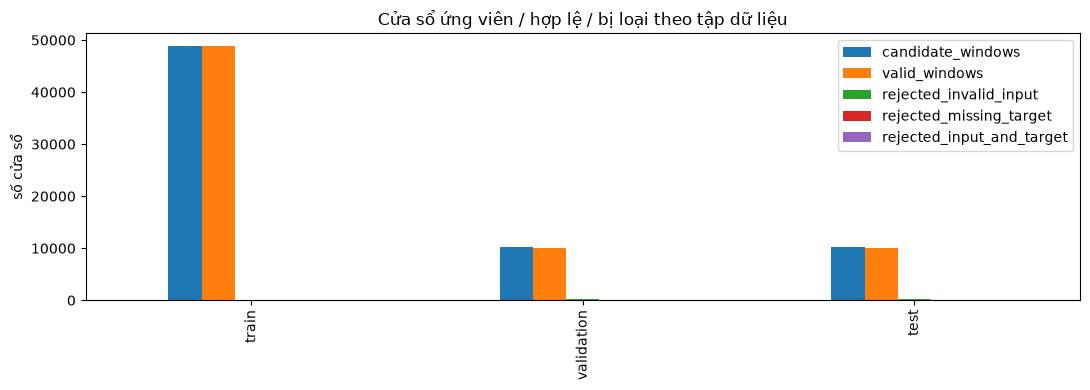

,reason,candidate_start,input_start,forecast_start
0,đầu vào không hợp lệ,969,2014-09-17 19:00:00,2014-09-24 19:00:00
1,mục tiêu bị thiếu,897,2014-09-14 19:00:00,2014-09-21 19:00:00


In [8]:
import matplotlib.pyplot as plt

if "reject_breakdown" not in globals():
    # Cho phép chạy riêng cell biểu đồ sau khi đã tạo ba DataFrame/Dataset ở §1–§3.
    reject_breakdown = pd.DataFrame({
        "train": window_rejection_diagnostics(train_df, FEATURES, TARGET, INPUT_WINDOW, HORIZON),
        "validation": window_rejection_diagnostics(val_df, FEATURES, TARGET, INPUT_WINDOW, HORIZON),
        "test": window_rejection_diagnostics(test_df, FEATURES, TARGET, INPUT_WINDOW, HORIZON),
    }).T.rename(columns={"rejected_invalid_input": "rejected_long_gap_input"})

plot_cols = ["candidate_windows", "valid_windows", "rejected_long_gap_input", "rejected_missing_target", "rejected_input_and_target"]
reject_breakdown[plot_cols].rename(columns={"rejected_long_gap_input": "rejected_invalid_input"}).plot(kind="bar", figsize=(11, 4))
plt.title("Cửa sổ ứng viên / hợp lệ / bị loại theo tập dữ liệu"); plt.ylabel("số cửa sổ"); plt.tight_layout(); plt.show()

def first_rejected_example(df, reason):
    values = df[FEATURES].to_numpy(float); target = df[TARGET].to_numpy(float)
    for start in range(max(0, len(df)-INPUT_WINDOW-HORIZON+1)):
        xb = not np.isfinite(values[start:start+INPUT_WINDOW]).all()
        yb = not np.isfinite(target[start+INPUT_WINDOW:start+INPUT_WINDOW+HORIZON]).all()
        if (reason == "đầu vào không hợp lệ" and xb) or (reason == "mục tiêu bị thiếu" and yb):
            return {"reason": reason, "candidate_start": start, "input_start": df[pp.TIMESTAMP_COLUMN].iloc[start], "forecast_start": df[pp.TIMESTAMP_COLUMN].iloc[start+INPUT_WINDOW]}
examples = pd.DataFrame([first_rejected_example(val_df, "đầu vào không hợp lệ"), first_rejected_example(val_df, "mục tiêu bị thiếu")]).dropna(how="all")
examples

**Phát hiện.** biểu đồ cột giữ nguyên phân rã cũ nhưng hiển thị nhãn chính xác `rejected_invalid_input`; bảng minh họa ứng viên cụ thể cho đầu vào không hợp lệ và mục tiêu bị thiếu.  
**Ảnh hưởng.** Mọi NaN/Inf trong đầu vào đều bị loại, không chỉ những giá trị do khoảng trống dài tạo ra.  
**Quyết định.** Chỉ sửa label hiển thị; không đổi `WeatherForecastDataset`.

**Phát hiện.** Bảng trên phân rã lý do loại cửa sổ thành đúng 3 nhóm được yêu
cầu theo dõi: `rejected_long_gap_input` (168h đầu vào chạm khoảng trống dài
còn sót NaN sau bù thiếu), `rejected_missing_target` (72h dự báo chạm mục tiêu
`T (degC)` bị thiếu — không bao giờ được bù thiếu), và
`rejected_input_and_target` (cả hai). Tập huấn luyện không có cửa sổ nào bị loại
(không có long/critical khoảng trống trong phạm vi huấn luyện, theo Notebook 01 §4), trong
khi tập xác thực/kiểm thử có cửa sổ bị loại vì chạm vào khoảng trống dài còn
sót lại sau bước bù thiếu (Notebook 02 §5/§7b). Cột thứ tư,
`split_boundary_violations`, luôn bằng 0 ở cả 3 tập dữ liệu — không phải một giả
định, mà là kết quả quét toàn bộ `len(dataset)` cửa sổ và so sánh với đúng
mốc `start`/`end` của từng tập dữ liệu trong `split_metadata.json`. Số liệu
`valid_windows` khớp chính xác với `len(dataset)` ở §4, chứng minh bảng phân
rã này không phải một quy tắc loại bỏ khác — chỉ là cùng một quy tắc được
tách ra để quan sát.

**Ảnh hưởng.** Nếu số cửa sổ bị loại vì `rejected_missing_target`/
`rejected_input_and_target` cao bất thường ở một tập dữ liệu, đó là dấu hiệu tập dữ liệu
đó chứa nhiều khoảng trống dài trùng đúng vùng dùng để tính dự báo — ảnh
hưởng trực tiếp đến số mẫu dùng để đánh giá mô hình (xác thực/kiểm thử ít mẫu
hơn dự kiến thuần túy từ số hàng). Nếu `split_boundary_violations` từng khác
0, đó sẽ là lỗi rò rỉ dữ liệu nghiêm trọng (rò rỉ dữ liệu) giữa các tập huấn luyện/
xác thực/kiểm thử — khẳng định kiểm tra ở trên biến điều này thành một lỗi chặn cứng
(lỗi chặn cứng) thay vì một giả định im lặng.

**Quyết định.** Không thay đổi quy trình — phân rã này thuần túy phục vụ
chẩn đoán; quy tắc loại bỏ thực tế vẫn do
`WeatherForecastDataset._find_valid_starts` quyết định, và việc không vượt
biên tập dữ liệu vẫn do cách mỗi `WeatherForecastDataset` chỉ được xây từ đúng một
tập dữ liệu (§3) quyết định, như đã chứng minh bằng số ở trên.

## 5. Kiểm tra Dòng thời gian

Xác nhận giai đoạn dự báo bắt đầu đúng một giờ sau khi giai đoạn đầu vào
kết thúc - không có khoảng trống, không chồng lấn - cho một mẫu từ mỗi tập dữ liệu.

In [9]:
def describe_window(dataset: WeatherForecastDataset, name: str, index: int = 0) -> None:
    bounds = dataset.window_bounds(index)
    gap_hours = (bounds["forecast_start"] - bounds["input_end"]).total_seconds() / 3600
    print(f"[{name}] mẫu {index}")
    print(f"  khoảng đầu vào:    {bounds['input_start']}  ->  {bounds['input_end']}")
    print(f"  khoảng dự báo: {bounds['forecast_start']}  ->  {bounds['forecast_end']}")
    print(f"  khoảng cách giữa cuối đầu vào và đầu dự báo: {gap_hours:.0f}giờ (kỳ vọng 1 giờ)\n")
    assert gap_hours == 1.0, "dự báo phải bắt đầu ngay sau khi đầu vào kết thúc"


describe_window(train_dataset, "train")
describe_window(val_dataset, "validation")
describe_window(test_dataset, "test")
print("ĐẠT: dự báo bắt đầu đúng 1 giờ sau khi đầu vào kết thúc trong mọi tập dữ liệu.")

[train] mẫu 0
  khoảng đầu vào:    2009-01-01 00:00:00  ->  2009-01-07 23:00:00
  khoảng dự báo: 2009-01-08 00:00:00  ->  2009-01-10 23:00:00
  khoảng cách giữa cuối đầu vào và đầu dự báo: 1giờ (kỳ vọng 1 giờ)

[validation] mẫu 0
  khoảng đầu vào:    2014-08-08 10:00:00  ->  2014-08-15 09:00:00
  khoảng dự báo: 2014-08-15 10:00:00  ->  2014-08-18 09:00:00
  khoảng cách giữa cuối đầu vào và đầu dự báo: 1giờ (kỳ vọng 1 giờ)

[test] mẫu 0
  khoảng đầu vào:    2015-10-20 17:00:00  ->  2015-10-27 16:00:00
  khoảng dự báo: 2015-10-27 17:00:00  ->  2015-10-30 16:00:00
  khoảng cách giữa cuối đầu vào và đầu dự báo: 1giờ (kỳ vọng 1 giờ)

ĐẠT: dự báo bắt đầu đúng 1 giờ sau khi đầu vào kết thúc trong mọi tập dữ liệu.


In [10]:
with open(ARTIFACTS_DIR / "split_metadata.json", encoding="utf-8") as f:
    split_metadata = json.load(f)

train_end = pd.Timestamp(split_metadata["train"]["end"])
val_start = pd.Timestamp(split_metadata["validation"]["start"])

last_train_bounds = train_dataset.window_bounds(len(train_dataset) - 1)
first_val_bounds = val_dataset.window_bounds(0)

print(f"Dự báo của mẫu huấn luyện cuối kết thúc:   {last_train_bounds['forecast_end']}  (tập huấn luyện kết thúc {train_end})")
print(f"Đầu vào của mẫu xác thực đầu bắt đầu:     {first_val_bounds['input_start']}  (tập xác thực bắt đầu {val_start})")

assert last_train_bounds["forecast_end"] <= train_end
assert first_val_bounds["input_start"] >= val_start
print("\nĐẠT: không cửa sổ huấn luyện nào chạm sang xác thực và không cửa sổ xác thực nào lùi vào huấn luyện.")

Dự báo của mẫu huấn luyện cuối kết thúc:   2014-08-08 09:00:00  (tập huấn luyện kết thúc 2014-08-08 09:00:00)
Đầu vào của mẫu xác thực đầu bắt đầu:     2014-08-08 10:00:00  (tập xác thực bắt đầu 2014-08-08 10:00:00)

ĐẠT: không cửa sổ huấn luyện nào chạm sang xác thực và không cửa sổ xác thực nào lùi vào huấn luyện.


## 6. Kiểm tra Lô dữ liệu

Bọc mỗi tập dữ liệu trong một bộ nạp dữ liệu và xác nhận chiều lô dữ liệu được thêm vào đúng cách.

In [11]:
BATCH_SIZE = 32
loaders = build_dataloaders(train_dataset, val_dataset, test_dataset, batch_size=BATCH_SIZE)

train_batch = next(iter(loaders["train"]))
print("Lô X:", train_batch["x"].shape, " (kỳ vọng [B, 168, n_features])")
print("Lô y:", train_batch["y"].shape, " (kỳ vọng [B, 72, 1])")
print("Lô mốc thời gian đầu vào:", train_batch["input_timestamps"].shape)
print("Lô mốc thời gian mục tiêu:", train_batch["target_timestamps"].shape)

assert train_batch["x"].shape == (BATCH_SIZE, INPUT_WINDOW, len(FEATURES))
assert train_batch["y"].shape == (BATCH_SIZE, HORIZON, 1)

# Kiểm tra theo hợp đồng WeatherBatch đã khóa của TV1 — cũng là phép kiểm tra mà code mô hình sử dụng.
validate_weather_batch(train_batch, n_features=len(FEATURES))
print("\nĐẠT: kích thước lô khớp [B,168,n_features] / [B,72,1] và vượt qua validate_weather_batch.")

Lô X: torch.Size([32, 168, 18])  (kỳ vọng [B, 168, n_features])
Lô y: torch.Size([32, 72, 1])  (kỳ vọng [B, 72, 1])
Lô mốc thời gian đầu vào: torch.Size([32, 168])
Lô mốc thời gian mục tiêu: torch.Size([32, 72])

ĐẠT: kích thước lô khớp [B,168,n_features] / [B,72,1] và vượt qua validate_weather_batch.


In [12]:
val_batch = next(iter(loaders["val"]))
test_batch = next(iter(loaders["test"]))
validate_weather_batch(val_batch, n_features=len(FEATURES))
validate_weather_batch(test_batch, n_features=len(FEATURES))
print("ĐẠT: các lô xác thực và kiểm thử cũng vượt qua bộ kiểm tra hợp đồng.")

ĐẠT: các lô xác thực và kiểm thử cũng vượt qua bộ kiểm tra hợp đồng.


## 7. Trực quan hóa mẫu

Chọn một mẫu cụ thể từ `train_dataset` và vẽ chuỗi 168h đầu vào cùng 72h dự báo
ở đơn vị gốc (độ C, %), bằng cách áp dụng ngược `scaler.mean_`/`scaler.scale_` cho
từng cột (chỉ để vẽ biểu đồ ở đây — không dùng cho huấn luyện hay đánh giá),
cùng với đặc trưng thời gian dạng chu kỳ `hour_sin`.

## 7b. Chẩn đoán chỉ báo thiếu dữ liệu

In [13]:
indicator_rows = []
for split, frame, dataset in [("train", train_df, train_dataset), ("validation", val_df, val_dataset), ("test", test_df, test_dataset)]:
    indicator_rows.append({"split": split, **missing_indicator_diagnostics(frame, dataset, pp.DIAGNOSTIC_INDICATOR_COLUMNS)})
missing_indicator_report = pd.DataFrame(indicator_rows).set_index("split")
missing_indicator_report

,processed_rows_with_indicator,valid_windows_with_indicator
split,,
train,0,0
validation,18,242
test,73,0


Theo quyết định thiết kế, các cột `missing_*` được giữ trong CSV đã xử lý chỉ để chẩn đoán/kiểm toán và không thuộc 18 đặc trưng đầu vào của mô hình. Bảng này tiếp tục kiểm tra hoạt động của các cột nhị phân mà không thay đổi lược đồ, bộ chuẩn hóa hay chỉ số mục tiêu.

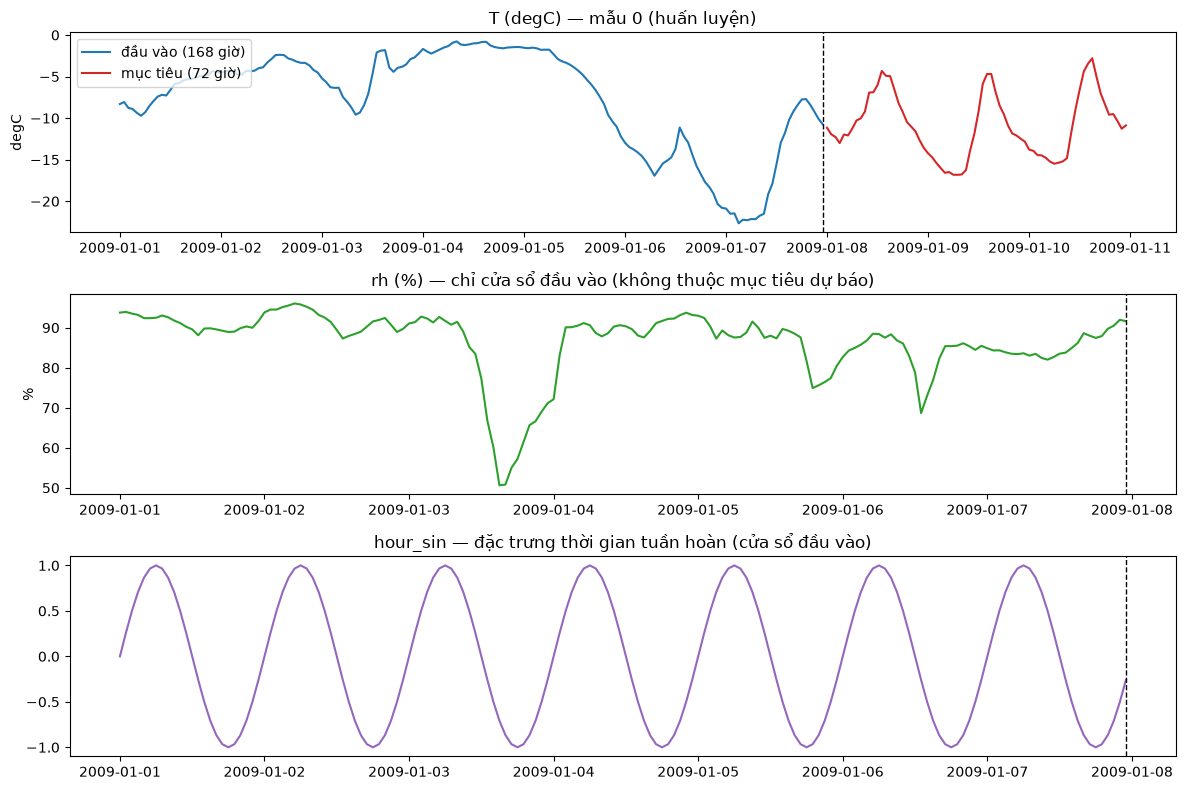

Đầu vào:  2009-01-01 00:00:00 -> 2009-01-07 23:00:00
Mục tiêu: 2009-01-08 00:00:00 -> 2009-01-10 23:00:00


In [14]:
import joblib
import matplotlib.pyplot as plt

sample_index = 0
sample = train_dataset[sample_index]
bounds = train_dataset.window_bounds(sample_index)
scaler = joblib.load(ARTIFACTS_DIR / "scaler.joblib")


def inverse_feature(scaled_values: np.ndarray, feature_name: str) -> np.ndarray:
    idx = FEATURES.index(feature_name)
    return scaled_values * scaler.scale_[idx] + scaler.mean_[idx]


input_ts = pd.to_datetime(sample["input_timestamps"].numpy(), unit="s")
target_ts = pd.to_datetime(sample["target_timestamps"].numpy(), unit="s")

input_temp = inverse_feature(sample["x"][:, FEATURES.index(TARGET)].numpy(), TARGET)
target_temp = inverse_feature(sample["y"][:, 0].numpy(), TARGET)
input_humidity = inverse_feature(sample["x"][:, FEATURES.index("rh (%)")].numpy(), "rh (%)")
input_hour_sin = inverse_feature(sample["x"][:, FEATURES.index("hour_sin")].numpy(), "hour_sin")

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=False)

axes[0].plot(input_ts, input_temp, color="tab:blue", label="đầu vào (168 giờ)")
axes[0].plot(target_ts, target_temp, color="tab:red", label="mục tiêu (72 giờ)")
axes[0].axvline(bounds["input_end"], color="black", linestyle="--", linewidth=1)
axes[0].set_title(f"T (degC) — mẫu {sample_index} (huấn luyện)")
axes[0].set_ylabel("degC")
axes[0].legend(loc="upper left")

axes[1].plot(input_ts, input_humidity, color="tab:green")
axes[1].axvline(bounds["input_end"], color="black", linestyle="--", linewidth=1)
axes[1].set_title("rh (%) — chỉ cửa sổ đầu vào (không thuộc mục tiêu dự báo)")
axes[1].set_ylabel("%")

axes[2].plot(input_ts, input_hour_sin, color="tab:purple")
axes[2].axvline(bounds["input_end"], color="black", linestyle="--", linewidth=1)
axes[2].set_title("hour_sin — đặc trưng thời gian tuần hoàn (cửa sổ đầu vào)")

fig.tight_layout()
plt.show()

print(f"Đầu vào:  {bounds['input_start']} -> {bounds['input_end']}")
print(f"Mục tiêu: {bounds['forecast_start']} -> {bounds['forecast_end']}")

## 7c. Nhiều mẫu huấn luyện/xác thực cố định

In [15]:
datasets = {"train": train_dataset, "validation": val_dataset}

def index_for_month(dataset, month):
    for idx in range(len(dataset)):
        if dataset.window_bounds(idx)["forecast_start"].month == month:
            return idx
    raise ValueError(f"Không có mẫu hợp lệ cho tháng={month}")

def variability_index(dataset, high=True):
    candidates = np.linspace(0, len(dataset) - 1, 300, dtype=int)
    scores = [float(dataset[idx]["x"][:, FEATURES.index(TARGET)].std()) for idx in candidates]
    return int(candidates[int(np.argmax(scores) if high else np.argmin(scores))])

choices = [
    ("Mùa đông", "train", index_for_month(train_dataset, 1), "forecast bắt đầu tháng 1"),
    ("Mùa hè", "train", index_for_month(train_dataset, 7), "forecast bắt đầu tháng 7"),
    ("Biến động cao", "validation", variability_index(val_dataset, True), "độ lệch chuẩn nhiệt độ lớn nhất trong 300 ứng viên tất định"),
    ("Giai đoạn ổn định", "train", variability_index(train_dataset, False), "độ lệch chuẩn nhiệt độ nhỏ nhất trong 300 ứng viên tất định"),
]
rows = []
for name, split, idx, reason in choices:
    b = datasets[split].window_bounds(idx)
    rows.append({"sample": name, "split": split, "dataset_index": idx, **b, "reason": reason, "selection": "quét tất định, không dùng tập kiểm thử"})
sample_catalog = pd.DataFrame(rows)
sample_catalog

,sample,split,dataset_index,input_start,input_end,forecast_start,forecast_end,reason,selection
0,Mùa đông,train,0,2009-01-01 00:00:00,2009-01-07 23:00:00,2009-01-08 00:00:00,2009-01-10 23:00:00,forecast bắt đầu tháng 1,"quét tất định, không dùng tập kiểm thử"
1,Mùa hè,train,4176,2009-06-24 00:00:00,2009-06-30 23:00:00,2009-07-01 00:00:00,2009-07-03 23:00:00,forecast bắt đầu tháng 7,"quét tất định, không dùng tập kiểm thử"
2,Biến động cao,validation,7644,2015-07-03 12:00:00,2015-07-10 11:00:00,2015-07-10 12:00:00,2015-07-13 11:00:00,std temperature lớn nhất trong 300 candidate d...,"quét tất định, không dùng tập kiểm thử"
3,Giai đoạn ổn định,train,35453,2013-01-17 05:00:00,2013-01-24 04:00:00,2013-01-24 05:00:00,2013-01-27 04:00:00,std temperature nhỏ nhất trong 300 candidate d...,"quét tất định, không dùng tập kiểm thử"


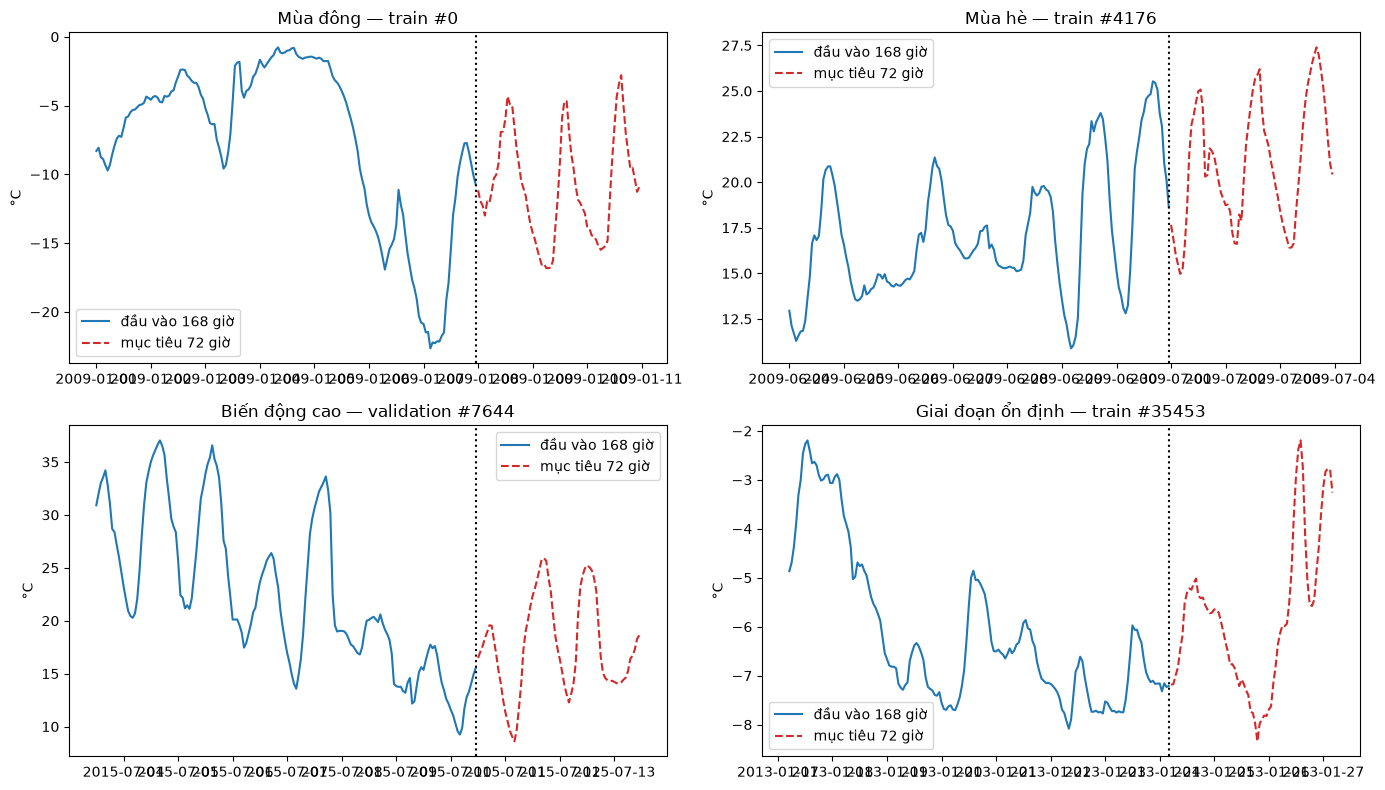

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, row in zip(axes.flat, sample_catalog.to_dict("records")):
    ds = datasets[row["split"]]; s = ds[row["dataset_index"]]; b = ds.window_bounds(row["dataset_index"])
    its = pd.to_datetime(s["input_timestamps"].numpy(), unit="s"); tts = pd.to_datetime(s["target_timestamps"].numpy(), unit="s")
    ax.plot(its, inverse_feature(s["x"][:, FEATURES.index(TARGET)].numpy(), TARGET), color="tab:blue", label="đầu vào 168 giờ")
    ax.plot(tts, inverse_feature(s["y"][:, 0].numpy(), TARGET), color="tab:red", linestyle="--", label="mục tiêu 72 giờ")
    ax.axvline(b["input_end"], color="black", linestyle=":"); ax.set_title(f'{row["sample"]} — {row["split"]} #{row["dataset_index"]}'); ax.set_ylabel("°C"); ax.legend()
fig.tight_layout(); plt.show()

**Phát hiện.** Bốn mẫu cố định bao phủ các bối cảnh kể chuyện khác nhau mà không dùng kiểm thử.  
**Ảnh hưởng.** Cho phép kiểm tra ranh giới và hình dạng chuỗi ngoài mẫu 0.  
**Quyết định.** Giữ mẫu 0 và bổ sung các mẫu tất định huấn luyện/xác thực.

**Phát hiện.** Biểu đồ trên cho thấy trực quan đúng những gì §5 đã xác nhận
bằng số: 168 giờ đầu vào (`x`, màu xanh) kết thúc đúng tại đường kẻ đứt, và 72
giờ dự báo (`y`, màu đỏ) bắt đầu ngay sau đó — không chồng, không hở; `hour_sin`
lặp lại mỗi 24 giờ đúng như thiết kế ở Notebook 01 §5.

**Ảnh hưởng.** Đây là bằng chứng trực quan cuối cùng rằng một `WeatherSample` thực sự
chứa dữ liệu liên tục, đúng đơn vị vật lý sau khi được giải chuẩn hóa — hữu ích
để phát hiện lỗi trực quan (vd. lệch trục thời gian, sai thứ tự cột) mà các khẳng định kiểm tra
số học ở §5/§6 có thể không bắt được.

**Quyết định.** Không thay đổi quy trình — ô này chỉ phục vụ kiểm tra trực quan thủ
công, bổ sung cho các khẳng định kiểm tra tự động ở §4/§5/§6.

## Tóm tắt

- `WeatherForecastDataset` xây dựng các cửa sổ trượt 168h vào / 72h ra
  một cách độc lập cho từng tập dữ liệu, loại bỏ bất kỳ cửa sổ nào chạm vào một giá trị
  thiếu - không bao giờ bịa đặt dữ liệu huấn luyện.
- Các cửa sổ không bao giờ vắt qua ranh giới tập dữ liệu vì mỗi tập dữ liệu chỉ được
  xây dựng từ các hàng của đúng tập dữ liệu đó.
- Các lô dữ liệu do `src/data/dataloader.py` tạo ra khớp với hợp đồng `WeatherBatch`
  (`x [B,168,F]`, `y [B,72,1]`, mốc thời gian được căn chỉnh) mà
  `src/data/dataset.py::validate_weather_batch` áp đặt cho mọi mô hình
  (Seq2Seq LSTM, Attention LSTM, Transformer).
- Nguyên nhân loại bỏ cửa sổ được phân thành chỉ đầu vào / chỉ mục tiêu / cả hai, và số
  mẫu hợp lệ khớp chính xác với `len(dataset)`; một mẫu cụ thể được vẽ trực quan
  (nhiệt độ, độ ẩm, đặc trưng thời gian) để đối chiếu với các khẳng định kiểm tra số học ở trên.
- Quy trình tập dữ liệu đã sẵn sàng để bàn giao cho bước huấn luyện mô hình.